In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns

In [2]:
arena_mask = np.array([
    [-1, -1, -1,  0,  1],
    [ 2,  3,  4,  5,  6],
    [ 7,  8,  9, 10, 11],
    [-1, -1, -1, 12, 13]
])

def map_coordinates_to_cell(x, y, x_min, x_max, y_min, y_max):
    n_rows = 4
    n_cols = 5
    

    x_norm = np.clip((x - x_min) / (x_max - x_min), 0, 0.999)
    y_norm = np.clip((y - y_min) / (y_max - y_min), 0, 0.999)
    
    col_idx = int(np.floor(x_norm * n_cols))
    row_idx = int(np.floor(y_norm * n_rows))
    
    cell_id = arena_mask[row_idx, col_idx]
     
    if cell_id == -1:
        return np.nan 
    return cell_id

In [10]:
df = pd.read_csv('./dlc/dlc/d8_m13_investigation_cropped.csv', index_col=0)

confidence_threshold = 0.8
df = df[df['Center_p'] > confidence_threshold]

df.head()

,Ear_left_x,Ear_left_y,Ear_left_p,Ear_right_x,Ear_right_y,Ear_right_p,Nose_x,Nose_y,Nose_p,Center_x,...,Corridor Animal_1 in zone_cumulative_percent,Shelter Animal_1 in zone,Shelter Animal_1 in zone_cumulative_time,Shelter Animal_1 in zone_cumulative_percent,Chamber Animal_1 distance,Corridor Animal_1 distance,Shelter Animal_1 distance,Chamber Animal_1 facing,Corridor Animal_1 facing,Shelter Animal_1 facing
0,992.0000,258.00000,0.999657,972.00000,285.00000,0.997645,996.00000,280.00000,0.999130,918.00000,...,0.0,0,0.0,0.0,923.27783,591.98987,601.51890,0,0,0
1,992.0000,258.00000,0.999612,972.00000,285.00000,0.997611,995.00000,280.00000,0.999108,918.00000,...,0.0,0,0.0,0.0,923.27783,591.98987,601.51890,0,0,0
2,993.7801,258.58800,0.999588,972.38410,284.18793,0.998304,995.00410,280.36810,0.998412,920.40424,...,0.0,0,0.0,0.0,927.29443,594.83405,603.11804,0,0,0
3,995.0000,259.19205,0.999481,972.79193,284.18018,0.998558,994.79193,280.98400,0.997715,921.41974,...,0.0,0,0.0,0.0,928.58270,595.96094,603.91940,0,0,0
4,996.4120,260.00000,0.999211,973.40010,284.39597,0.998685,994.97210,281.81207,0.996174,922.59216,...,0.0,0,0.0,0.0,929.91010,597.23190,604.89320,0,0,0


In [12]:
min_x, max_x = df['Center_x'].min(), df['Center_x'].max()
min_y, max_y = df['Center_y'].min(), df['Center_y'].max()
width = max_x - min_x
height = max_y - min_y
aspect_ratio = height / width

print(f"Arena Dimensions: W={width:.1f}, H={height:.1f}")
print(f"Aspect Ratio (H/W): {aspect_ratio:.3f}")

n_rows = 5
n_cols = int(np.round(n_rows / aspect_ratio))

print(f'grid shape: ({n_rows} x {n_cols})')

Arena Dimensions: W=1098.8, H=359.7
Aspect Ratio (H/W): 0.327
grid shape: (5 x 15)


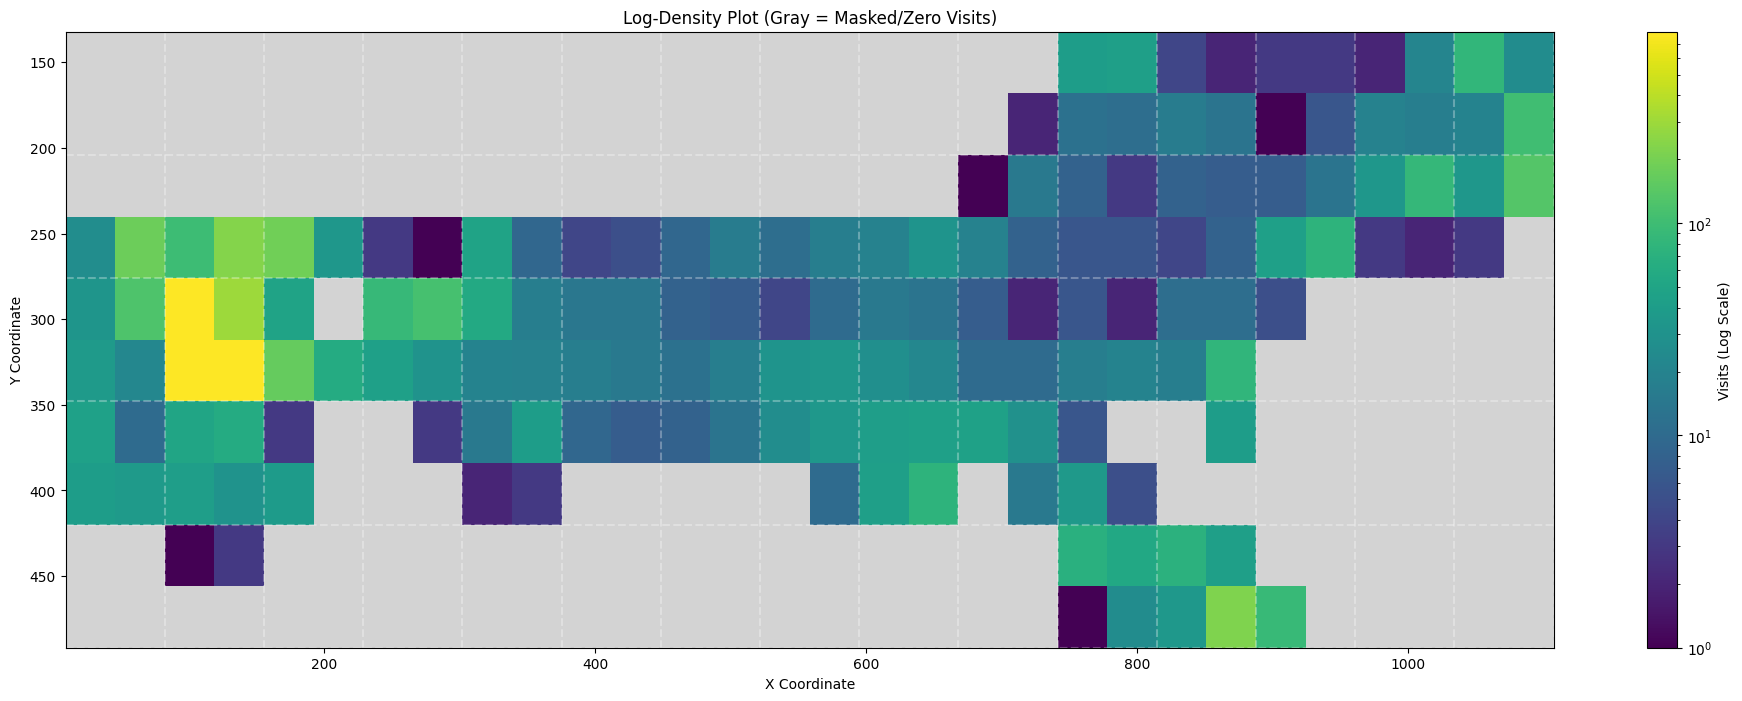

In [21]:
plt.figure(figsize=(24, 8))
ax = plt.gca()
ax.set_facecolor('lightgray') 


counts, xedges, yedges, image = plt.hist2d(
    df['Center_x'], df['Center_y'], 
    bins=[n_cols*2, n_rows*2],
    norm=colors.LogNorm(),
    cmap='viridis',
    cmin=1
)


x_grid = np.linspace(df['Center_x'].min(), df['Center_x'].max(), n_cols + 1)
y_grid = np.linspace(df['Center_y'].min(), df['Center_y'].max(), n_rows + 1)

for x in x_grid:
    plt.axvline(x, color='white', linestyle='--', alpha=0.3)
for y in y_grid:
    plt.axhline(y, color='white', linestyle='--', alpha=0.3)

%matplotlib inline
plt.colorbar(image, label='Visits (Log Scale)')
plt.gca().invert_yaxis()
plt.title(f"Log-Density Plot (Gray = Masked/Zero Visits)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")

plt.show()

In [22]:
mask = np.zeros((n_rows, n_cols), dtype=int)
for _, row in df.iterrows():
    c = int((row['Center_x'] - min_x) / (max_x - min_x) * n_cols)
    r = int((row['Center_y'] - min_y) / (max_y - min_y) * n_rows)
    # Clip to be safe
    c = min(max(c, 0), n_cols - 1)
    r = min(max(r, 0), n_rows - 1)
    mask[r, c] = 1

mask

array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
       [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
       [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0]])